In [1]:
import warnings
warnings.filterwarnings('ignore')

import xarray as xr
import geopandas as gp
import regionmask
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib import colors as mplc
import numpy as np

import utils

## Shapefile

In [2]:
wind_gdf = gp.read_file('/g/data/xv83/unseen-projects/outputs/wind-drought/grids.shp')

In [3]:
wind_gdf

,grid,geometry
0,NEM_2030,"MULTIPOLYGON Z (((146.12455 -41.09714 0, 146.3..."
1,SE_2030,"MULTIPOLYGON Z (((143.39392 -37.77456 0, 143.6..."
2,NWIS,"POLYGON Z ((116.6832 -23.33436 0, 116.67898 -2..."
3,SWIS,"POLYGON Z ((115.77377 -34.51252 0, 115.77212 -..."


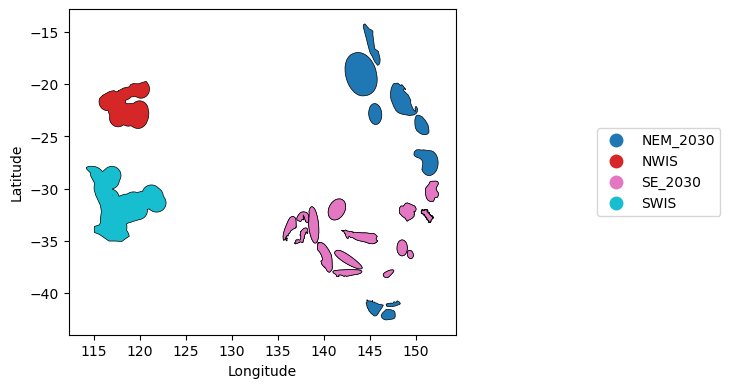

In [4]:
wind_gdf.plot(
    figsize=[5, 5],
    column='grid',
    cmap='tab10',
    legend=True,
    linewidth=0.5,
    edgecolor='black',
    legend_kwds={'loc': 'right', 'bbox_to_anchor': (1.7, 0.5)},
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [5]:
wind_combined_gdf = wind_gdf.dissolve()
wind_combined_gdf.grid[0] = 'combined'

Convert to a regionmask regions object...

In [6]:
wind_regions = regionmask.from_geopandas(wind_combined_gdf, names='grid', name='wind regions')

In [7]:
type(wind_regions)

regionmask.core.regions.Regions

In [8]:
print(wind_regions)

<regionmask.Regions 'wind regions'>
overlap:  None

Regions:
0 r0 combined

[1 regions]


## DCPP data

In [9]:
indir_highres = '/g/data/oi10/replicas/CMIP6/DCPP/EC-Earth-Consortium/EC-Earth3/dcppA-hindcast/s1990-r1i1p1f1/day/sfcWind/gr/v20201215'
infile_highres = 'sfcWind_day_EC-Earth3_dcppA-hindcast_s1990-r1i1p1f1_gr_19901101-19911031.nc'
inpath_highres = f'{indir_highres}/{infile_highres}'

indir_lowres = '/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1990-r1i1p2f1/day/sfcWind/gn/v20190429'
infile_lowres = 'sfcWind_day_CanESM5_dcppA-hindcast_s1990-r1i1p2f1_gn_19910101-20001231.nc'
inpath_lowres = f'{indir_lowres}/{infile_lowres}'

In [10]:
ds_highres = xr.open_dataset(inpath_highres)

In [11]:
ds_highres = utils.model_fixes(ds_highres)

In [12]:
ds_lowres = xr.open_dataset(inpath_lowres)

In [13]:
ds_lowres = utils.model_fixes(ds_lowres)

## Masks

In [14]:
mask_dict = {}

In [15]:
mask_dict[('centre', 'highres')] = wind_regions.mask_3D(ds_highres)

In [28]:
mask_dict[('centre', 'lowres')] = wind_regions.mask_3D(ds_lowres)

In [16]:
mask_dict[('frac', 'highres')] = wind_regions.mask_3D_frac_approx(ds_highres)

In [29]:
mask_dict[('frac', 'lowres')] = wind_regions.mask_3D_frac_approx(ds_lowres)

In [17]:
mask_dict[('10pct', 'highres')] = mask_dict[('frac', 'highres')] >= 0.1

In [30]:
mask_dict[('10pct', 'lowres')] = mask_dict[('frac', 'lowres')] >= 0.1

In [18]:
mask_dict[('50pct', 'highres')] = mask_dict[('frac', 'highres')] >= 0.5

In [32]:
mask_dict[('50pct', 'lowres')] = mask_dict[('frac', 'lowres')] >= 0.5

In [33]:
titles = {
    'frac': 'fraction overlap',
    'centre': 'cells with centre point in region',
    '10pct': 'cells with > 10% overlap with region',
    '50pct': 'cells with > 50% overlap with region'
}

def plot_mask(mask, model):
    """Plot mask"""

    assert mask in ['frac', 'centre', '10pct', '50pct']
    assert model in ['highres', 'lowres']

    fig = plt.figure(figsize=[12, 7])
    ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())

    colorbar = True if mask == 'frac' else False
    mask_dict[(mask, model)].plot(ax=ax1, transform=ccrs.PlateCarree(), cmap='Blues', add_colorbar=colorbar)

    ax1.add_geometries(wind_combined_gdf.geometry, ccrs.PlateCarree(), facecolor='none', linewidth=2.0, edgecolor='orange')
    ax1.coastlines()
    ax1.add_feature(cartopy.feature.STATES)
    ax1.set_extent([110, 155.5, -8, -45], crs=ccrs.PlateCarree())
    ax1.set_title(f'{titles[mask]} - {model} model')
    plt.show()

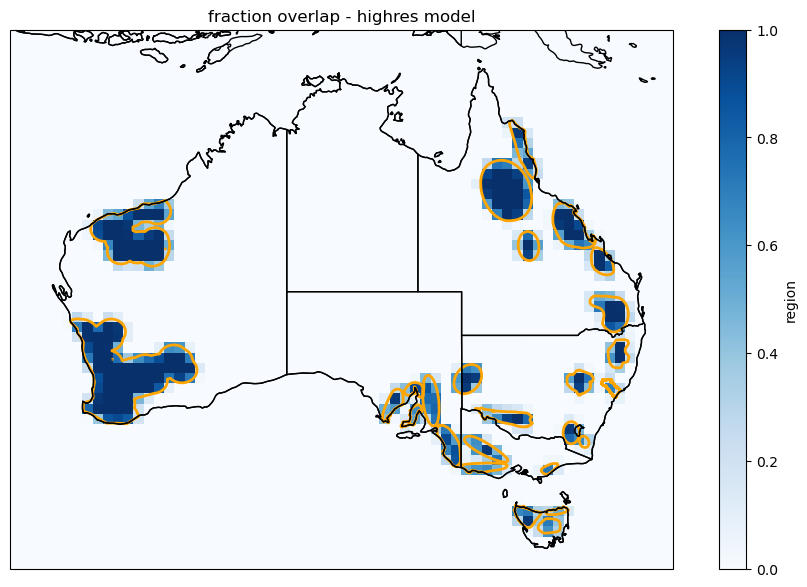

In [34]:
plot_mask('frac', 'highres')

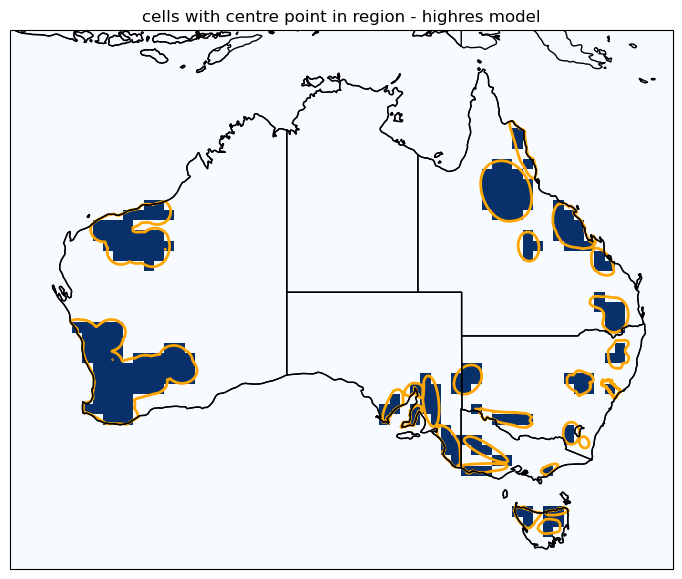

In [27]:
plot_mask('centre', 'highres')

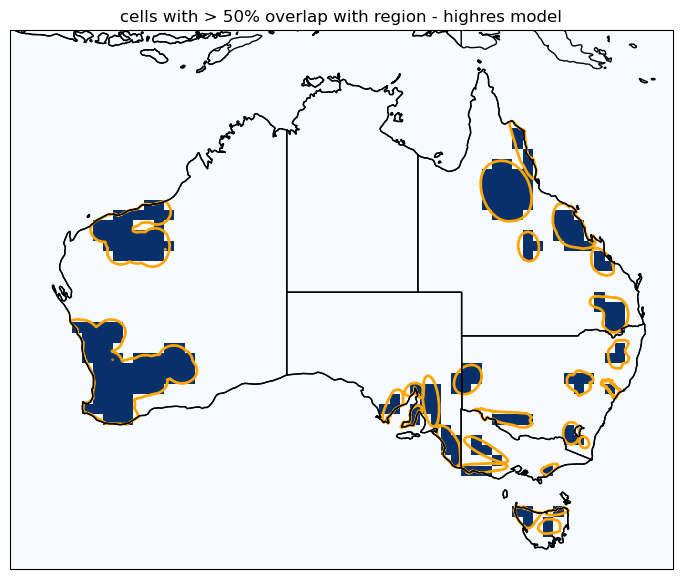

In [35]:
plot_mask('50pct', 'highres')

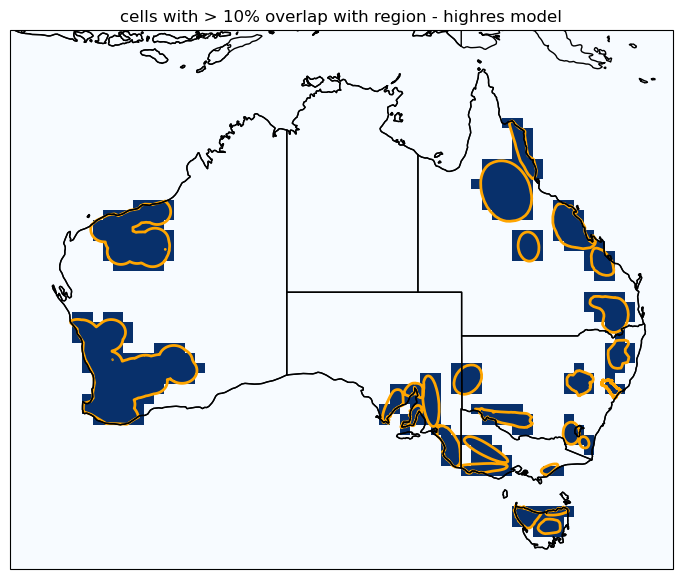

In [36]:
plot_mask('10pct', 'highres')

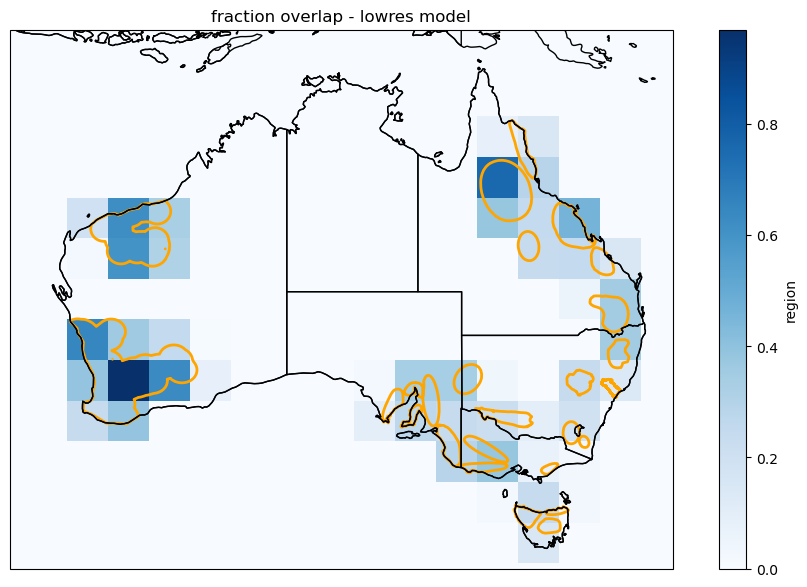

In [37]:
plot_mask('frac', 'lowres')

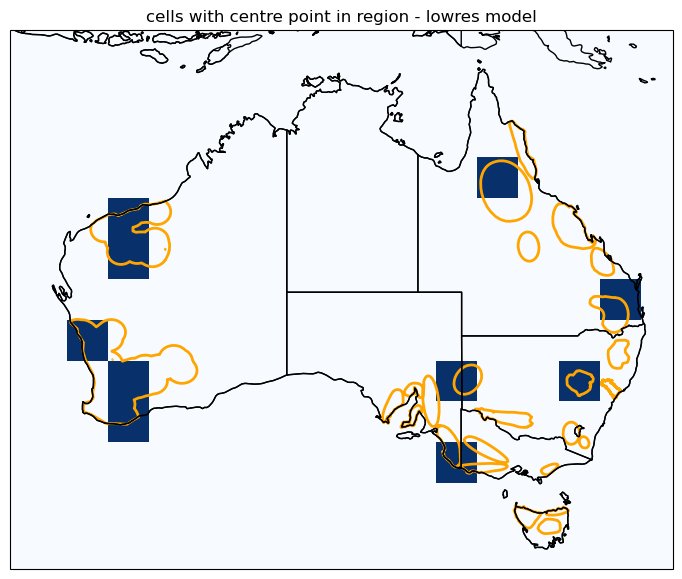

In [38]:
plot_mask('centre', 'lowres')

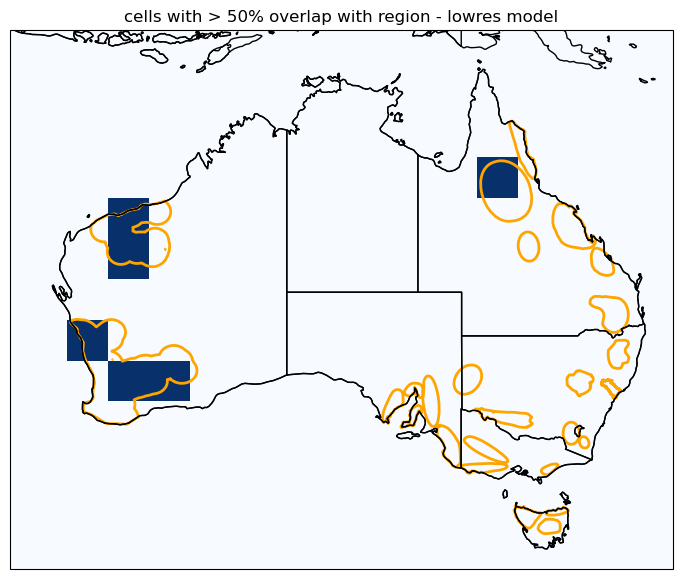

In [39]:
plot_mask('50pct', 'lowres')

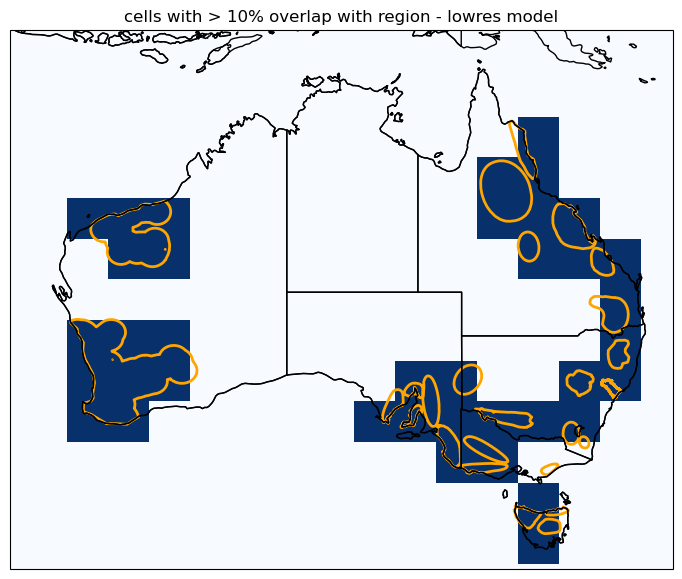

In [40]:
plot_mask('10pct', 'lowres')